<b><u>Data Set link:</b></u> <a>https://www.kaggle.com/datasets/rjmanoj/credit-card-customer-churn-prediction</a>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace = True)
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype= 'int64')
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train,X_test,y_trian,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [16]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [17]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.fit_transform(X_test)

In [19]:
X_train_scalled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [31]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

In [32]:
model = Sequential()

# model.add(Dense(3,activation='sigmoid',input_dim = 11))
model.add(Dense(11,activation='relu',input_dim = 11)) 
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# toatal train able parameters 
p = ( (11*3)+3 )+ ( (3*1)+1 )
print(f"Total Trainable parameters: {p}")

Total Trainable parameters: 40


In [35]:
model.compile(loss= 'binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [36]:
history = model.fit(X_train_scalled,y_trian,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5013 - loss: 0.7469 - val_accuracy: 0.7906 - val_loss: 0.5118
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4638 - val_accuracy: 0.8050 - val_loss: 0.4470
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8072 - loss: 0.4330 - val_accuracy: 0.8094 - val_loss: 0.4283
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8170 - loss: 0.4194 - val_accuracy: 0.8200 - val_loss: 0.4157
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8266 - loss: 0.4093 - val_accuracy: 0.8269 - val_loss: 0.4038
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8347 - loss: 0.3982 - val_accuracy: 0.8363 - val_loss: 0.3906
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8423 - loss: 0.3857 - val_accuracy: 0.8444 - val_loss: 0.3765
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8473 - loss: 0.3733 - val_accu

In [26]:
# layer 0
model.layers[0].get_weights()

[array([[ 0.22757104, -0.48137498, -0.01258104, -0.05301075,  0.21398945,
         -0.18712229,  0.10644158,  0.12328592, -0.0855333 ,  0.5376425 ,
         -0.01322043],
        [ 0.7056848 , -0.22316107, -0.27523115,  0.3566772 , -0.7409835 ,
         -0.5403757 , -0.01397443,  0.02064687,  1.1170695 , -0.48944515,
         -0.09124741],
        [-0.0102938 , -0.08963922, -0.02508658, -0.2148517 ,  0.3347066 ,
          0.04725338, -0.04068981,  0.21866599, -0.12978175, -0.6143629 ,
         -0.54674613],
        [ 0.25931594,  0.556762  , -0.00932304, -0.1575765 , -0.09111606,
         -0.13849723, -0.76406115, -0.6553011 , -0.07321951,  0.03893321,
         -0.3726572 ],
        [ 0.55273056, -0.91549444,  0.12226245,  1.2321512 ,  1.0596365 ,
         -0.12661889, -1.0851486 , -0.05565105, -0.21178415,  0.44268414,
          0.02060635],
        [-0.05584178, -0.13855524, -0.00371524, -0.2133217 ,  0.08847784,
          0.12989476, -0.00404615, -0.10762329,  0.0514547 , -0.2281285

In [27]:
# layer 1 
model.layers[1].get_weights()

[array([[ 8.97793531e-01,  2.59000123e-01, -1.23467135e+00,
         -9.18147340e-02, -2.39837661e-01,  5.47936141e-01,
          6.61524951e-01,  6.22521162e-01, -3.78884435e-01,
         -5.00309467e-01, -1.23670034e-01],
        [-1.68369517e-01,  5.45520782e-01, -4.45880502e-01,
         -3.64259519e-02, -3.33209395e-01, -3.42008382e-01,
          3.82223725e-01, -1.16505817e-01,  6.31967783e-01,
         -6.05755866e-01, -2.29930490e-01],
        [-6.94139063e-01, -1.82862073e-01,  4.34021324e-01,
          7.22704828e-01,  1.83317557e-01, -4.16353732e-01,
         -6.20879471e-01, -1.94749758e-01,  8.30419734e-02,
         -3.24280143e-01,  7.50290394e-01],
        [-9.50002670e-01, -2.73943812e-01, -6.05785064e-02,
          3.00612479e-01,  1.31497815e-01, -3.01787913e-01,
         -3.44813794e-01,  8.15194368e-01, -7.63911366e-01,
          2.19309360e-01, -6.26579344e-01],
        [-3.02830100e-01,  2.96603799e-01, -5.10353088e-01,
         -5.12614489e-01, -1.09824753e+00,  

In [28]:
y_log = model.predict(X_test_scalled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [30]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.868

In [37]:
import matplotlib.pyplot as plt

In [38]:
history.history

{'accuracy': [0.5012500286102295,
  0.800000011920929,
  0.8071874976158142,
  0.8170312643051147,
  0.8265625238418579,
  0.8346874713897705,
  0.8423437476158142,
  0.8473437428474426,
  0.8492187261581421,
  0.8532812595367432,
  0.8537499904632568,
  0.8525000214576721,
  0.8550000190734863,
  0.856249988079071,
  0.8578125238418579,
  0.8559374809265137,
  0.8596875071525574,
  0.8587499856948853,
  0.859375,
  0.8606250286102295,
  0.8603125214576721,
  0.8615624904632568,
  0.8606250286102295,
  0.8621875047683716,
  0.8634374737739563,
  0.8631250262260437,
  0.8606250286102295,
  0.8623437285423279,
  0.8645312786102295,
  0.8642187714576721,
  0.8634374737739563,
  0.8631250262260437,
  0.8631250262260437,
  0.8637499809265137,
  0.86328125,
  0.8629687428474426,
  0.8628125190734863,
  0.8623437285423279,
  0.8635937571525574,
  0.862500011920929,
  0.8631250262260437,
  0.864062488079071,
  0.8653125166893005,
  0.8648437261581421,
  0.8631250262260437,
  0.8653125166893005

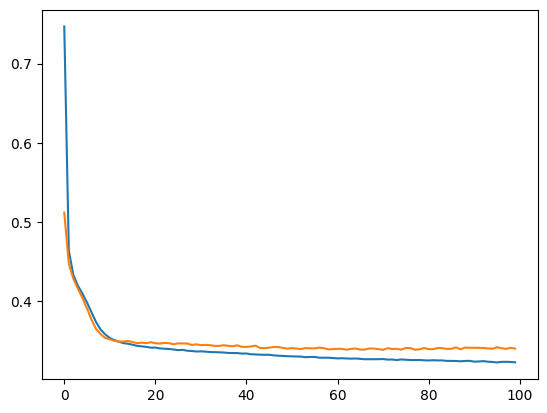

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

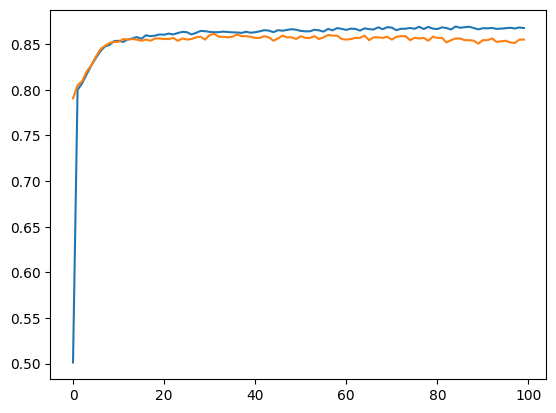

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])